## NuAncestor Telescope Visibility

The following script is written to plot a diversity of relevant quantities for the nuAncestor mission. The script takes as input the data computed with the FreeFlyer script which is part of the repository. <br> The quantities that we are currently investigating are the satellite-telescope distance, velocity, acceleration. Furthermore, the visibility of the satellite is studied and the corresponding required tracking speed. 

Version 06/2026 by Pedro de S. C. Leonardo

(Original from Blanca Crazzolara)

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

In [ ]:
# Choose inclination!
# Choose whether to save the figures or not
# Choose whether to show the requirement thresholds or not

inclination = 0  # eg. 0, 20, or 40
savefig = False
show_requirements = False

folder = f"Results_i{inclination}/"

In [52]:
colors = ['r', 'blueviolet', 'cyan', 'orange', 'lime']
label = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_windows(folder, filepath, title, ylabel, cols, saving_name, xlim, inclination, savefig=True):
    folder = Path(folder)
    plots_folder = folder / "plots"

    if savefig:
        plots_folder.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(folder / filepath, skiprows=3, sep=r'\s+')

    df = np.asarray(df)
    dat = 1.0 * df.T
    df = df.T

    days = np.floor(dat[0]) + 0.5
    hour = (dat[0] - np.floor(dat[0])) * 24
    DT = hour[1] - hour[0]

    plt.figure(figsize=(8,5))
    plt.minorticks_on()
    plt.grid(which="both", zorder=-1.0, alpha=0.3)

    for i in cols:
        x = days[dat[i+1] == 1]
        y = hour[dat[i+1] == 1]

        plt.bar(x=x, height=DT, width=1, bottom=y, label=label[i],
                color=colors[i], alpha=0.5, zorder=1)

    plt.title(f"{title}: i={inclination}°")
    plt.xlabel("days")
    plt.ylabel(ylabel)
    plt.legend()
    plt.xlim(*xlim)
    plt.ylim(0,24)
    plt.tight_layout()

    if savefig:
        plt.savefig(plots_folder / Path(saving_name).name, dpi=300, bbox_inches="tight")

    plt.show()

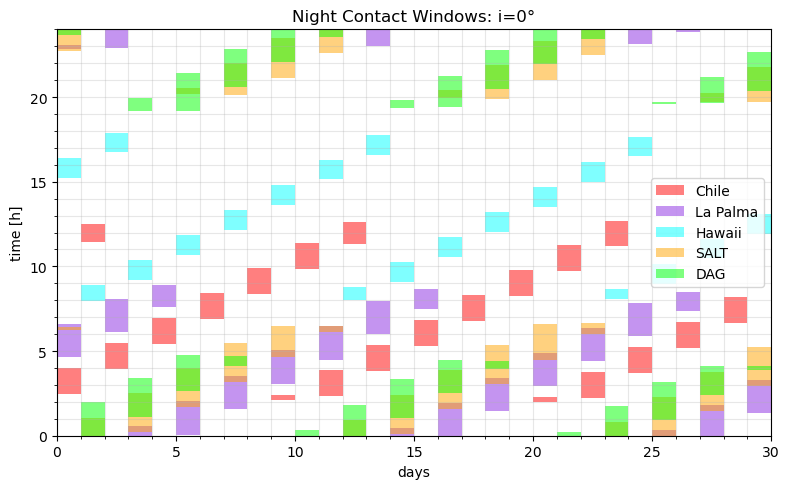

In [53]:
contact_windows(folder, "InContact.txt", "Night Contact Windows", "time [h]",
                [0,1,2,3,4], "InContact.png", [0,30], inclination, savefig)

In [54]:
def plotting(folder, filepath, title, ylabel, cols, saving_name, xlim, inclination,
             savefig=True, show_requirements=True):
    folder = Path(folder)
    input_path = folder / filepath
    plots_folder = folder / "plots"
    if savefig:
        plots_folder.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(input_path, skiprows=3, sep=r"\s+")
    df = np.asarray(df).T
    dat = 1.0 * df
    dat[dat == 0] = np.nan

    plt.figure(figsize=(8, 5))
    for i in cols:
        plt.plot(dat[0], dat[i + 1], label=label[i], linewidth=1.0, color=colors[i])


    if show_requirements and title == "Azimuthal Tracking Speed":
        plt.axhline(600, color="black", linestyle="--", linewidth=1.2,
                    label="Req: 600 arcsec/s")
    elif show_requirements and title == "Elevation Tracking Speed":
        plt.axhline(15, color="black", linestyle="--", linewidth=1.2,
                    label="Req: 15 arcsec/s")


    plt.title(f"{title}: i={inclination}°")
    plt.xlabel("time [d]")
    plt.ylabel(ylabel)
    plt.legend()
    plt.xlim(*xlim)
    plt.tight_layout()
    if savefig:
        plt.savefig(plots_folder / Path(saving_name).name, dpi=300, bbox_inches="tight")
    plt.show()

    if title == "Distance":
        v_r = np.ones_like(df[:, :-1])
        a_r = np.ones_like(df[:, :-2])
        dt = (df[0, 1] - df[0, 0]) * 24 * 3600

        for i in cols:
            r = 1.0 * df[i + 1]
            v_r[i + 1] = (r[1:] - r[:-1]) / dt
            a_r[i + 1] = (v_r[i + 1, 1:] - v_r[i + 1, :-1]) / dt

        v_r[(df[:, :-1] == 0) | (df[:, 1:] == 0)] = 0
        a_r[(v_r[:, :-1] == 0) | (v_r[:, 1:] == 0)] = 0
        v_r[v_r == 0] = np.nan
        a_r[a_r == 0] = np.nan

        plt.figure(figsize=(8, 5))
        for i in cols:
            plt.plot(df[0, 1:], v_r[i + 1], label=label[i], linewidth=1.0, color=colors[i])
        plt.title(f"Line-of-Sight Velocity: i={inclination}°")
        plt.xlabel("time [d]")
        plt.ylabel("km/s")
        plt.legend()
        plt.xlim(*xlim)
        plt.tight_layout()
        if savefig:
            plt.savefig(plots_folder / "Velocity.png", dpi=300, bbox_inches="tight")
        plt.show()

        C = 299792.458

        plt.figure(figsize=(8, 5))
        for i in cols:
            plt.plot(df[0, 1:], v_r[i + 1] / C, label=label[i], linewidth=1.0, color=colors[i])
        plt.title(f"Doppler Shift: i={inclination}°")
        plt.xlabel("time [d]")
        plt.ylabel(r"$\Delta\lambda/\lambda$")
        plt.legend()
        plt.xlim(*xlim)
        plt.tight_layout()
        if savefig:
            plt.savefig(plots_folder / "DopplerShift.png", dpi=300, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(8, 5))
        for i in cols:
            plt.plot(df[0, 1:-1], 100000 * a_r[i + 1], label=label[i], linewidth=1.0, color=colors[i])
        plt.title(f"Line-of-Sight Acceleration: i={inclination}°")
        plt.xlabel("time [d]")
        plt.ylabel(r"cm/s$^2$")
        plt.legend()
        plt.xlim(*xlim)
        plt.tight_layout()
        if savefig:
            plt.savefig(plots_folder / "Acceleration.png", dpi=300, bbox_inches="tight")
        plt.show()

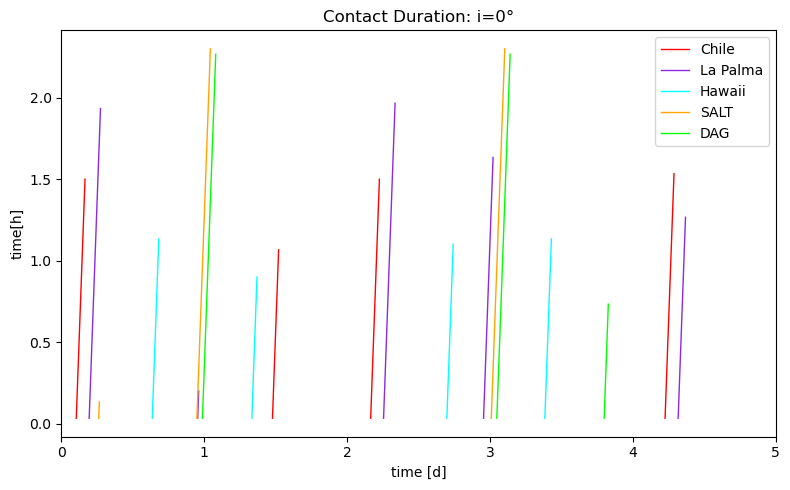

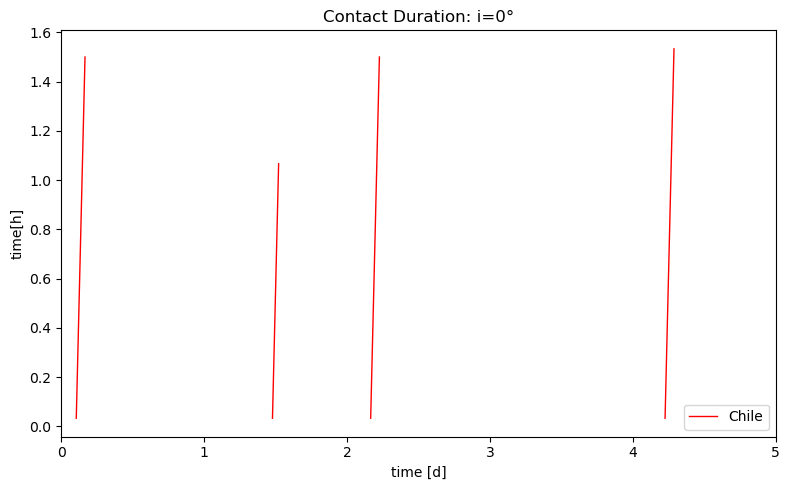

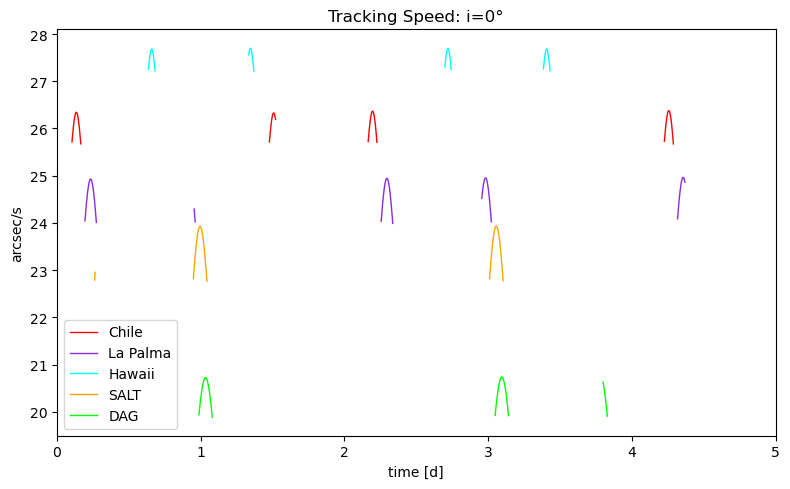

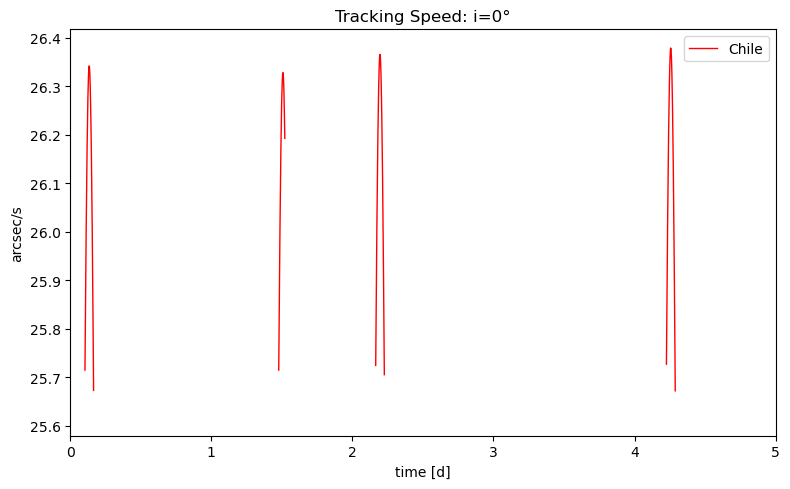

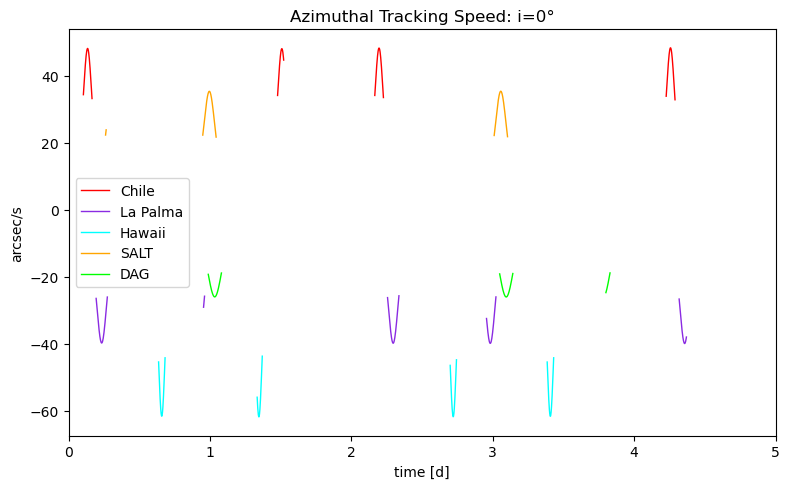

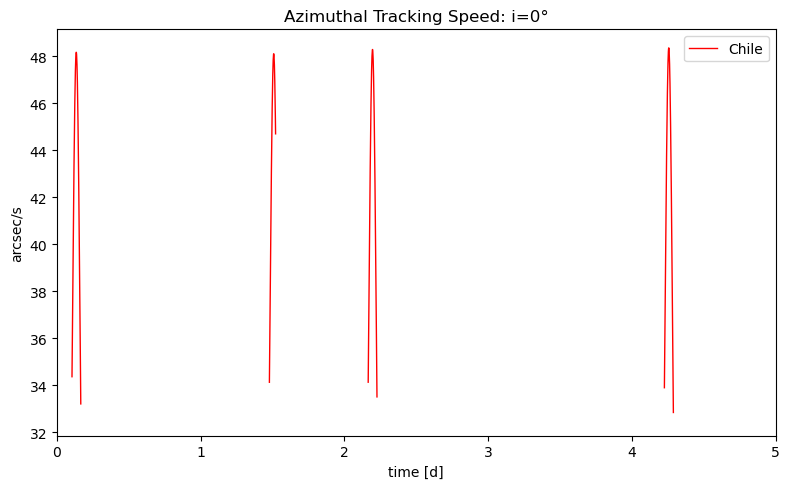

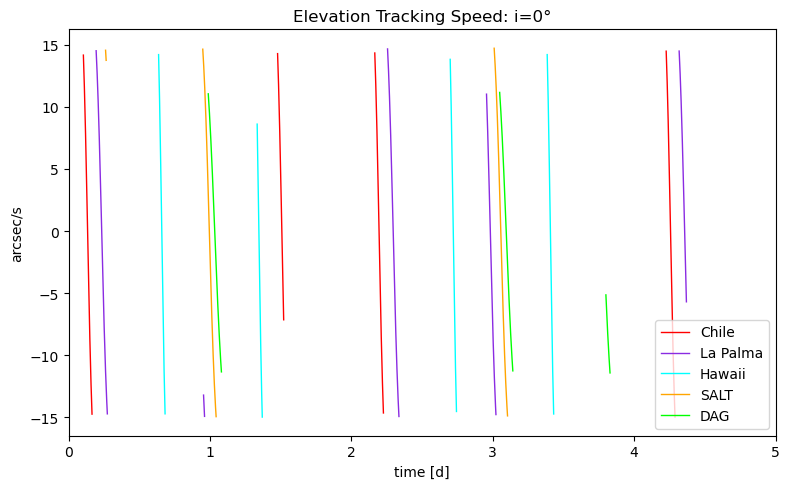

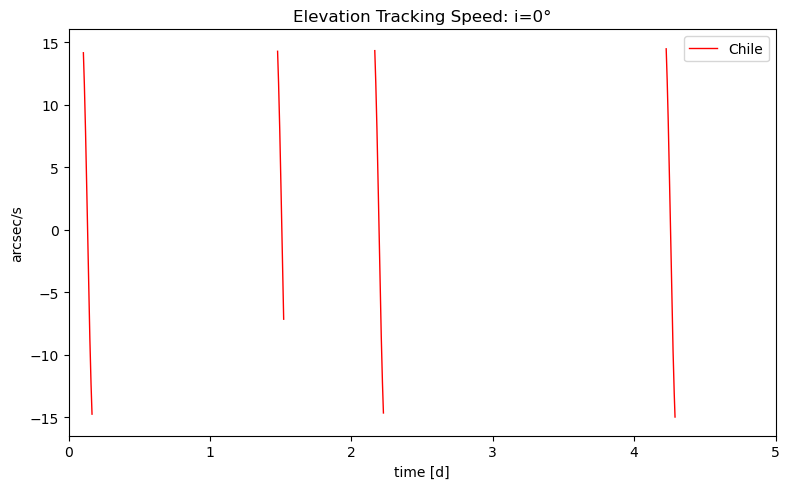

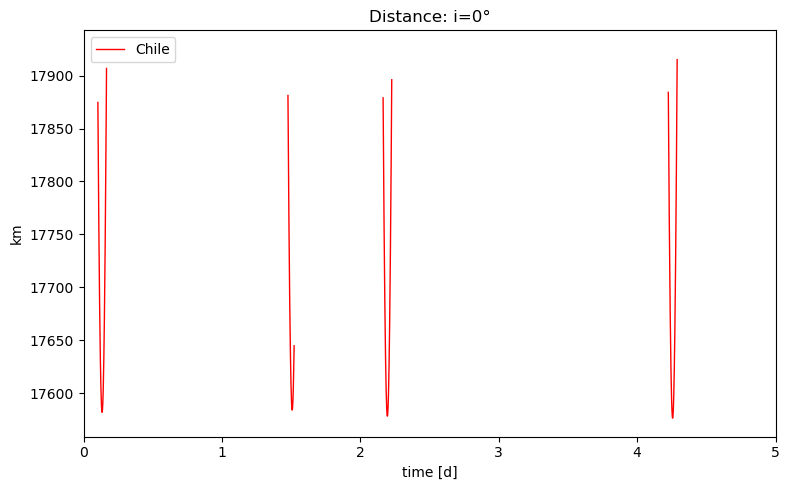

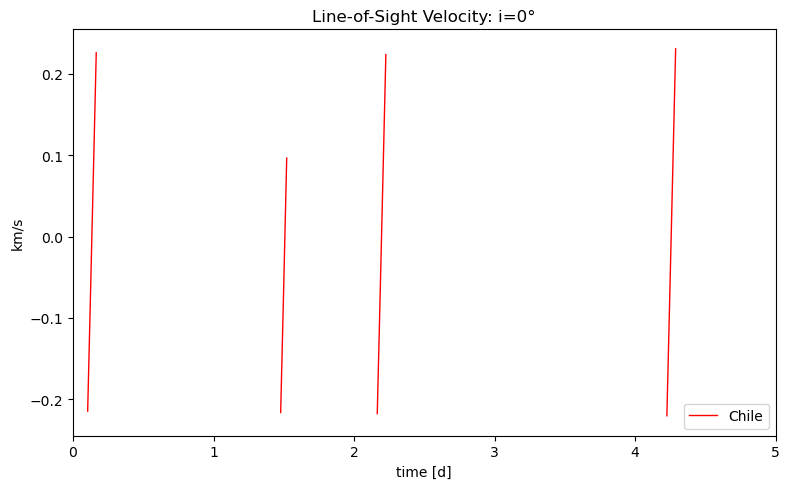

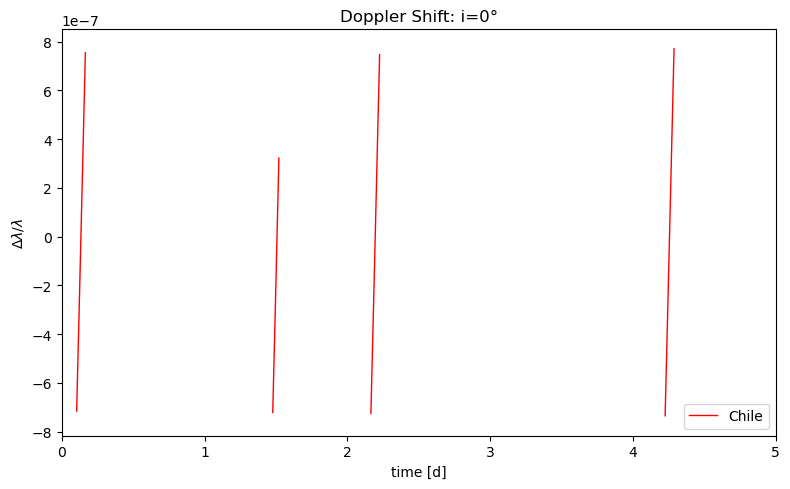

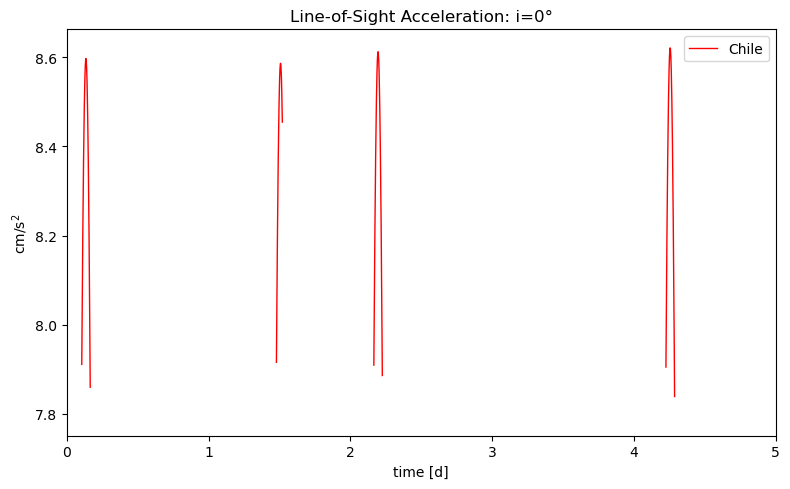

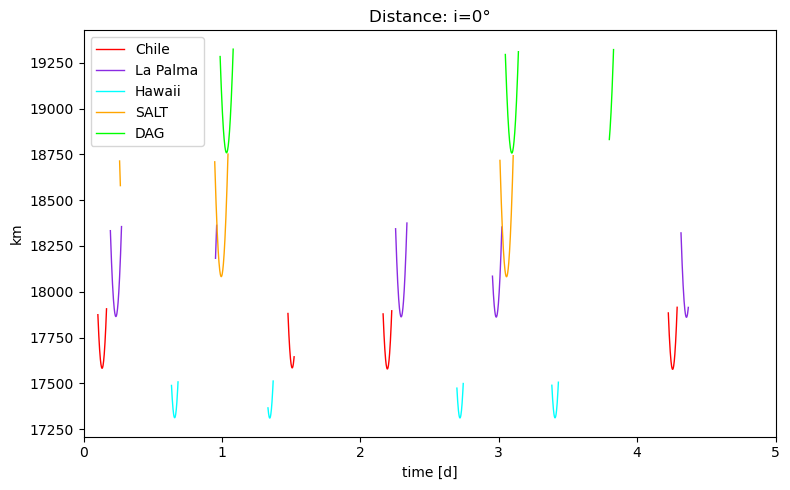

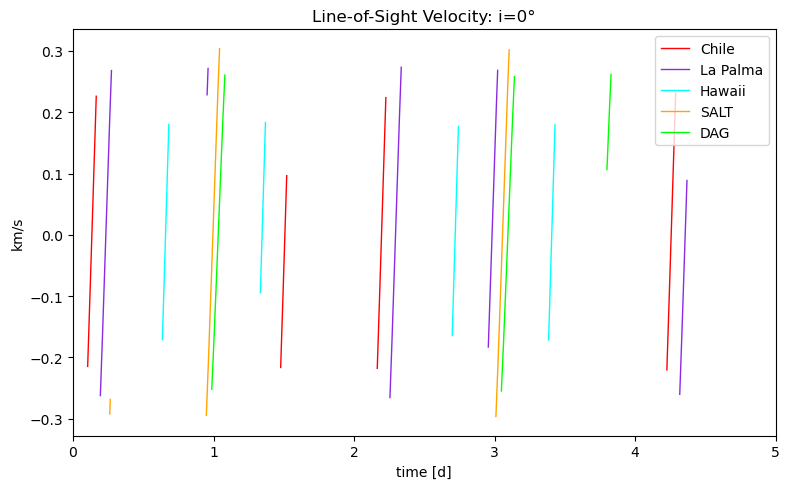

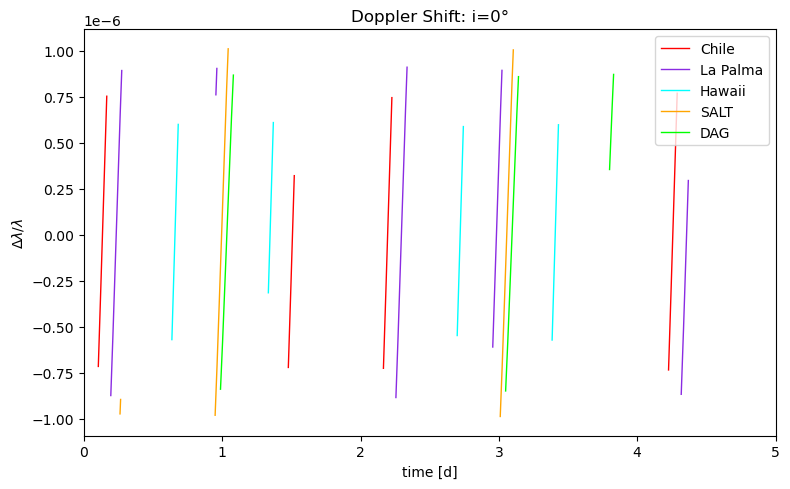

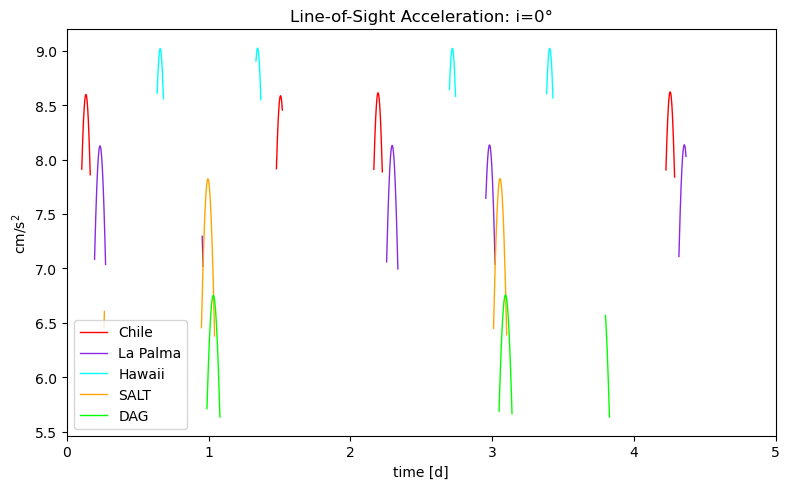

In [ ]:
xlim = [0,5]

plotting(folder,"ContactDuration.txt", "Contact Duration", "time[h]", [0,1,2,3,4], "ContactTime.png", xlim, inclination, savefig, show_requirements)
plotting(folder,"ContactDuration.txt", "Contact Duration", "time[h]", [0], "ContactTimeChile.png", xlim, inclination, savefig, show_requirements)

plotting(folder,"Tracking Speed.txt", "Tracking Speed", "arcsec/s", [0,1,2,3,4], "TrackingSpeed.png", xlim, inclination, savefig, show_requirements)
plotting(folder,"Tracking Speed.txt", "Tracking Speed", "arcsec/s", [0], "TrackingSpeedChile.png", xlim, inclination, savefig, show_requirements)

plotting(folder,"Azimuthal Speed.txt", "Azimuthal Tracking Speed", "arcsec/s", [0,1,2,3,4], "AzimuthalSpeed.png", xlim, inclination, savefig, show_requirements)
plotting(folder,"Azimuthal Speed.txt", "Azimuthal Tracking Speed", "arcsec/s", [0], "AzimuthalSpeedChile.png", xlim, inclination, savefig, show_requirements)

plotting(folder,"Elevation Speed.txt", "Elevation Tracking Speed", "arcsec/s", [0,1,2,3,4], "ElevationSpeed.png", xlim, inclination, savefig, show_requirements)
plotting(folder,"Elevation Speed.txt", "Elevation Tracking Speed", "arcsec/s", [0], "ElevationSpeedChile.png", xlim, inclination, savefig, show_requirements)

plotting(folder,"Distances.txt", "Distance", "km", [0], "DistanceChile.png", xlim, inclination, savefig, show_requirements)
plotting(folder,"Distances.txt", "Distance", "km", [0,1,2,3,4], "Distance.png", xlim, inclination, savefig, show_requirements)